Open_Ended:01


Name:Fiza zahid

Roll No:24F-AI-028

Project Name:Employee Attrition Analyzer

Date:08-10-2026

Instructor:
Sir Hamza Farooqi


In [2]:

import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)



In [7]:
import kagglehub

path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
print("Path to dataset files:", path)

# path is a folder, so find the csv inside it
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
print(csv_files)

df = pd.read_csv(csv_files[0])


Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset
['/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv']


In [8]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [14]:
# AnalyZing our Dataset
print("Shape:", df.shape)
# checking null values
print("Missing values:", df.isnull().sum().sum())
# checking duplicates
print("Duplicates:", df.duplicated().sum())
# checking no: of attrition
print(df["Attrition"].value_counts())
# checking data information like columns,rows, datatypes
df.info()
# getting statistical summary
df.describe()


Shape: (1470, 35)
Missing values: 0
Duplicates: 0
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender 

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


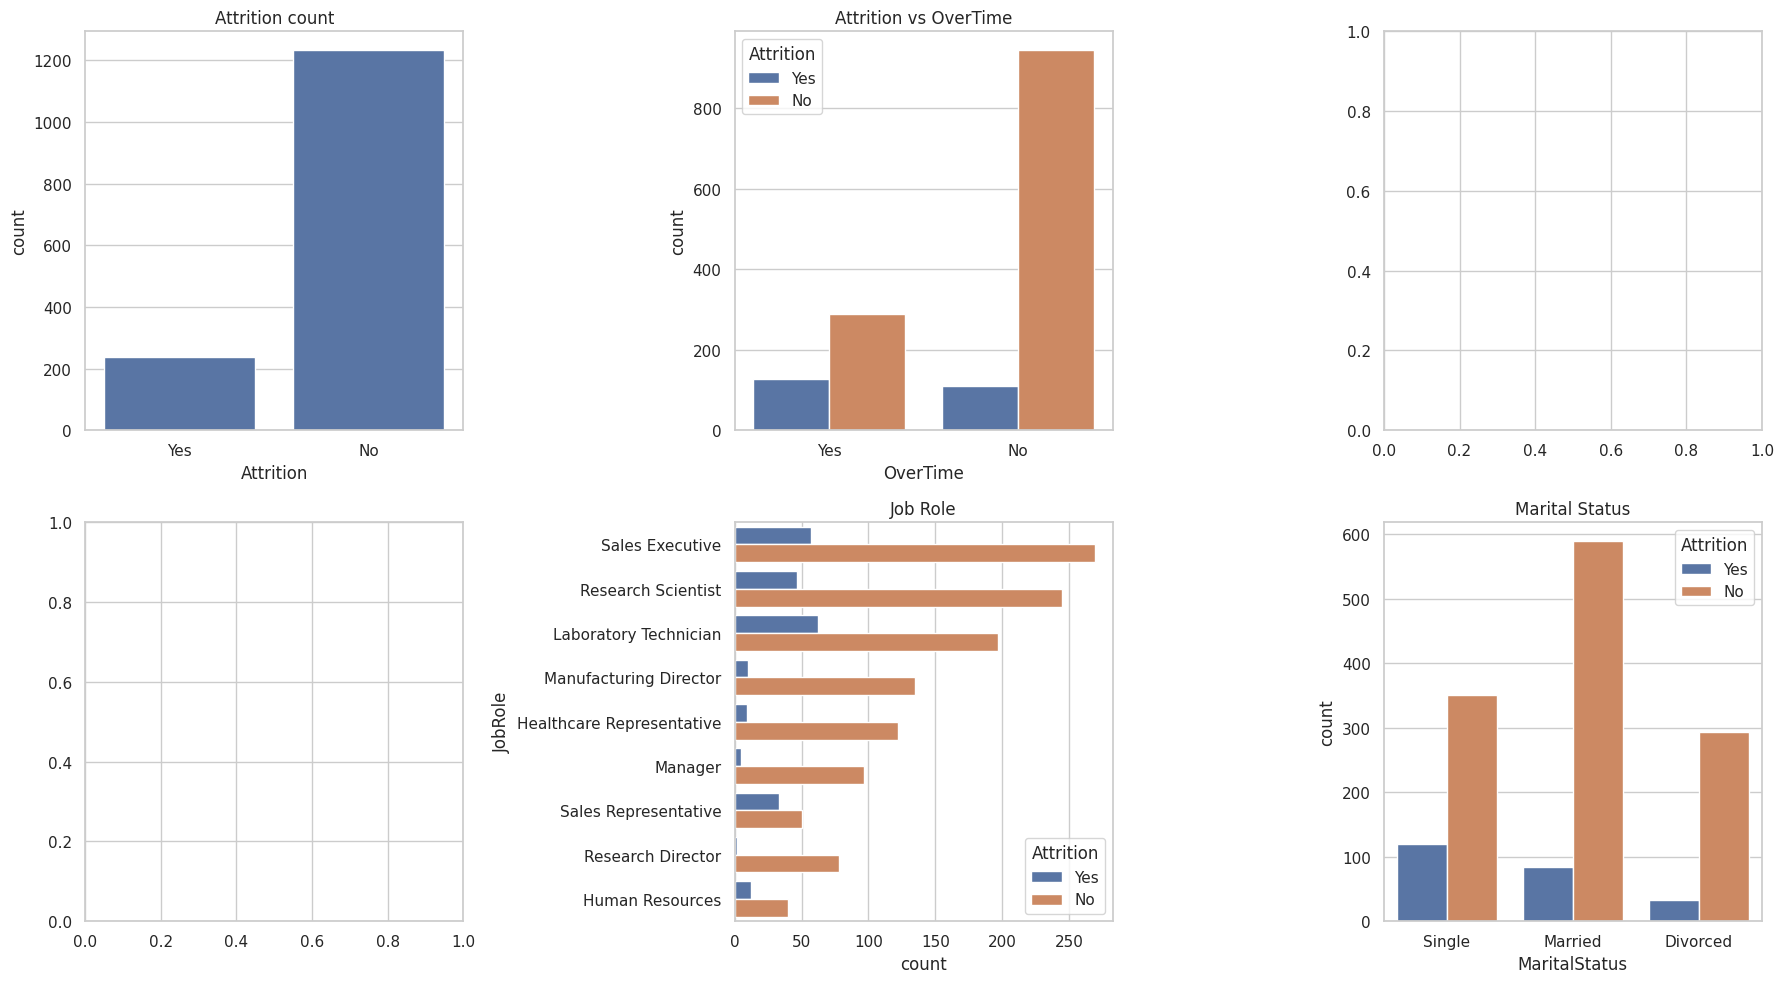

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.countplot(data=df, x="Attrition", ax=axes[0, 0]);                    axes[0, 0].set_title("Attrition count")
sns.countplot(data=df, x="OverTime", hue="Attrition", ax=axes[0, 1]);    axes[0, 1].set_title("Attrition vs OverTime")
sns.countplot(data=df, y="JobRole", hue="Attrition", ax=axes[1, 1]);     axes[1, 1].set_title("Job Role")
sns.countplot(data=df, x="MaritalStatus", hue="Attrition", ax=axes[1, 2]); axes[1, 2].set_title("Marital Status")
plt.tight_layout(); plt.show()


tmp = df.copy()
tmp["Attrition"] = tmp["Attrition"].map({"Yes": 1, "No": 0})

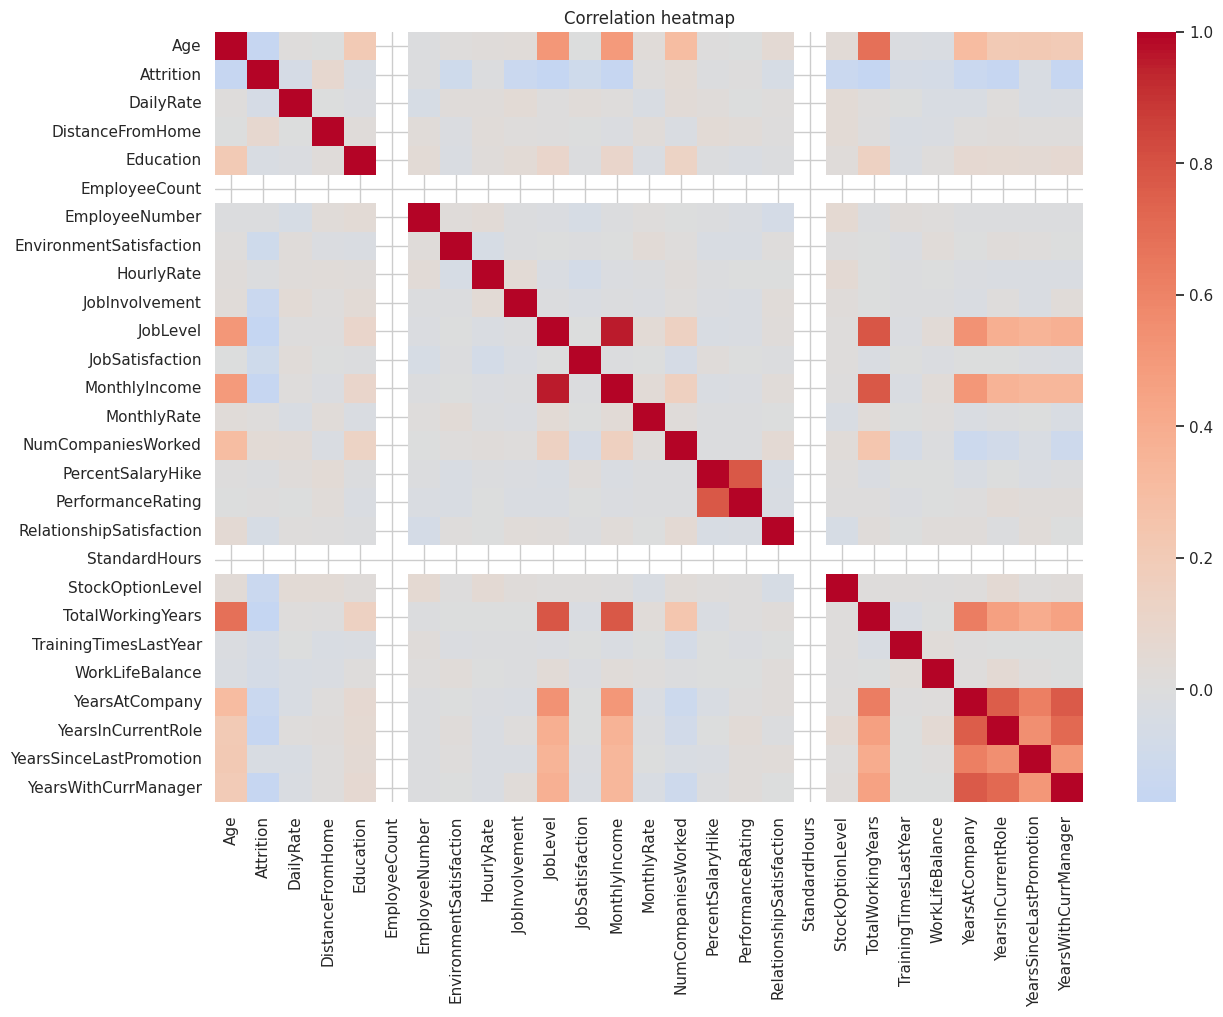

In [63]:
plt.figure(figsize=(14, 10))
sns.heatmap(tmp.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation heatmap"); plt.show()

In [67]:
# Fresh copy from original dataframe
data = df.copy()

# Drop columns with no information (constant values or just an ID)
drop_cols = [c for c in ["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"] if c in data.columns]
drop_cols += [c for c in data.columns if data[c].nunique() == 1 and c not in drop_cols]
data = data.drop(columns=drop_cols)
print("Dropped:", drop_cols)

# Encode target if it is not already encoded
if data["Attrition"].dtype == 'object':
    data["Attrition"] = data["Attrition"].map({"Yes": 1, "No": 0})

assert data["Attrition"].isnull().sum() == 0

Dropped: ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']


In [47]:
X = data.drop(columns="Attrition")
y = data["Attrition"]

# Split BEFORE scaling/encoding (avoids data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer(
    [("num", StandardScaler(), num_cols),
     ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
    sparse_threshold=0)   # dense output, avoids sparse matrix errors

In [48]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                            class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=3,
                                            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
}

pipelines = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(name, "trained")

Logistic Regression trained
Decision Tree trained
Random Forest trained


In [53]:
# Generate predictions from the trained pipelines
log_pred = pipelines["Logistic Regression"].predict(X_test)
dt_pred = pipelines["Decision Tree"].predict(X_test)
rf_pred = pipelines["Random Forest"].predict(X_test)

models = {
    "Logistic Regression": log_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

for name, predictions in models.items():
    accuracy = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(name)
    print("Accuracy:", accuracy)
    print("F1 Score:", f1)
    print("----------------------")

Logistic Regression
Accuracy: 0.7517006802721088
F1 Score: 0.45112781954887216
----------------------
Decision Tree
Accuracy: 0.7687074829931972
F1 Score: 0.43333333333333335
----------------------
Random Forest
Accuracy: 0.8401360544217688
F1 Score: 0.3561643835616438
----------------------


In [54]:
print("Logistic Regression")
print(classification_report(y_test, log_pred))

print("Decision Tree")
print(classification_report(y_test, dt_pred))

print("Random Forest")
print(classification_report(y_test, rf_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.35      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.71      0.65       294
weighted avg       0.83      0.75      0.78       294

Decision Tree
              precision    recall  f1-score   support

           0       0.90      0.81      0.85       247
           1       0.36      0.55      0.43        47

    accuracy                           0.77       294
   macro avg       0.63      0.68      0.64       294
weighted avg       0.82      0.77      0.79       294

Random Forest
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       247
           1       0.50      0.28      0.36        47

    accuracy                           0.84       294
   macro avg       0.69      0.61      0.63       294
weighted avg       0.81   

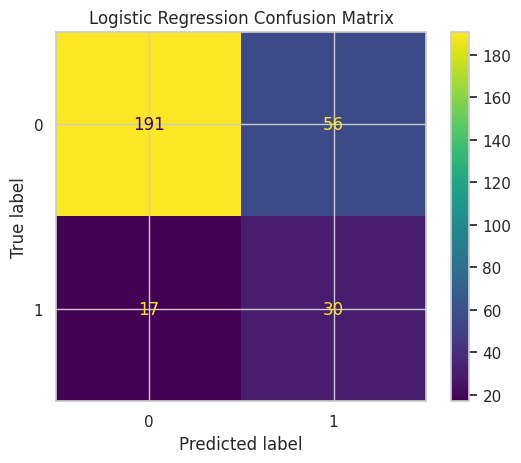

In [55]:
cm = confusion_matrix(y_test, log_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

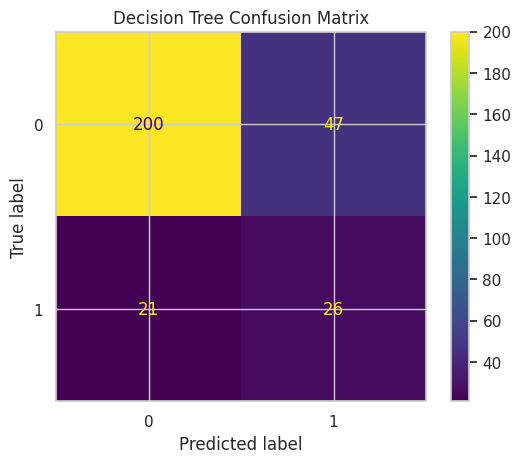

In [56]:
cm = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

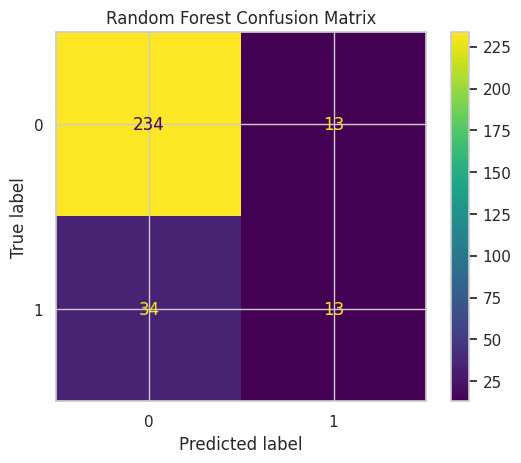

In [57]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [59]:
# Extract the trained random forest model and preprocessor from the pipeline
rf_pipeline = pipelines["Random Forest"]
rf_model = rf_pipeline.named_steps["model"]
preprocessor = rf_pipeline.named_steps["prep"]

# Get feature importances
importance = rf_model.feature_importances_

# Get the correct feature names after transformation (StandardScaler + OneHotEncoder)
encoded_cat_cols = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)
feature_names = num_cols + list(encoded_cat_cols)

# Map importances to feature names
feature_importance = pd.Series(
    importance,
    index=feature_names
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

print(feature_importance.head(10))

MonthlyIncome           0.077595
Age                     0.064020
TotalWorkingYears       0.057950
YearsAtCompany          0.050877
DailyRate               0.047563
DistanceFromHome        0.040401
MonthlyRate             0.040349
YearsWithCurrManager    0.039838
HourlyRate              0.036787
OverTime_No             0.036490
dtype: float64


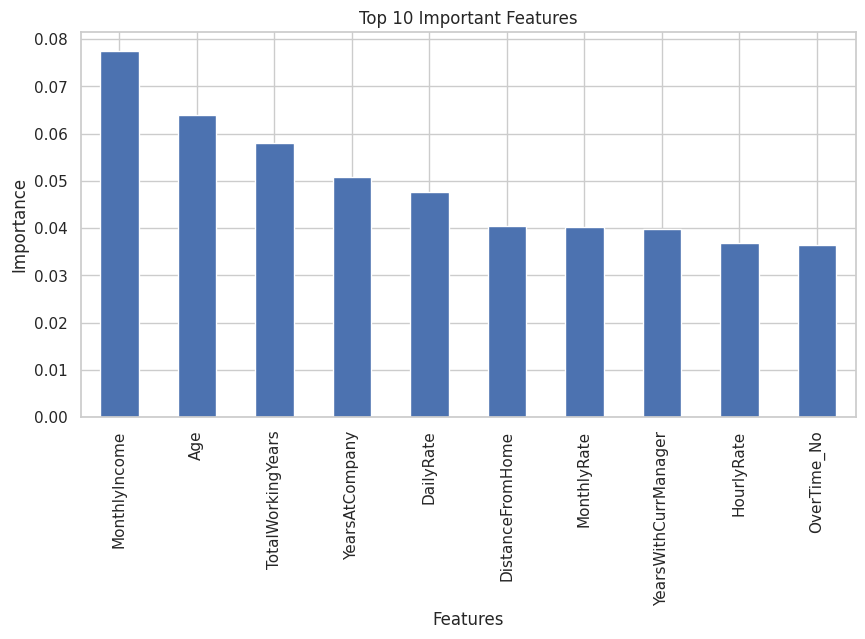

In [60]:
# checking feature importance
feature_importance.head(10).plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()